<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP2_millikan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksperimen Tetes Minyak Millikan
**Fisika Laboratorium II — ITS Surabaya**

Analisis lengkap: kecepatan terminal → jari-jari → muatan (Rising & Floating) → kuantisasi → histogram Gaussian → regresi linear.

## Cell 1 — Import Library

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("=" * 65)
print("   EKSPERIMEN TETES MINYAK MILLIKAN")
print("   Fisika Laboratorium II — ITS Surabaya")
print("=" * 65)
print("\n✅  Library berhasil diimport.")

   EKSPERIMEN TETES MINYAK MILLIKAN
   Fisika Laboratorium II — ITS Surabaya

✅  Library berhasil diimport.


## Cell 2 — Input Data Pengamatan

In [14]:
# Format kolom: No | t_down (s) | U_r (V) | t_up (s) | U_s (V)
# d = 1.00e-3 m (jarak 1 skala grid), sama untuk semua tetesan

data_raw = [
    # No   t_down   U_r    t_up    U_s
    [1,   13.541,   450,   7.12,    314],
    [2,   12.749,   457,   16.892,   262],
    [3,    7.568,   470,   11.866,   252],
    [4,    5.105,   469,    3.668,  205],
    [5,   13.796,   552,   11.985,   392],
    [6,    7.297,   522,    9.722,  393],
    [7,    7.175,   448,    4.576,  268],
    [8,   12.13,   263.2,  13.85,  138.9],
    [9,   11.72,   170.9,  13.57,   90.4],
    [10,  16.65,   121.7,  20.83,   67.7],
    [11,  12.45,   310,    17.9,   186.1],
    [12,  15.75,   107.4,  33.79,   71.4],
    [13,   6.61,   390.5,  13.75,  263.7],
    [14,  18.81,   123.4,  26.57,   69.9],
    [15,   6.83,   347.4,  10.56,  205.7],
    [16,   6.77,   334.3,  41.11,  294.4],
    [17,  12.33,   360.5,  23.23,  234.9],
    [18,  20.27,   155,    18.11,   75.1],
    [19,   9.37,   189.2,  30.27,  140.2],
    [20,  19.96,    95.8,  41.1,    66.5],
]

d_jarak = 1.00e-3  # jarak satu skala grid (m)
df = pd.DataFrame(data_raw, columns=['No', 't_down', 'U_r', 't_up', 'U_s'])

print("\n📋  DATA HASIL PENGAMATAN")
print("-" * 65)
print(f"{'No':>3} | {'d (m)':>10} | {'t_down (s)':>10} | {'U_r (V)':>7} | {'t_up (s)':>8} | {'U_s (V)':>7}")
print("-" * 65)
for _, row in df.iterrows():
    print(f"{int(row['No']):>3} | {d_jarak:>10.2e} | {row['t_down']:>10.2f} | "
          f"{row['U_r']:>7.1f} | {row['t_up']:>8.2f} | {row['U_s']:>7.1f}")
print("-" * 65)


📋  DATA HASIL PENGAMATAN
-----------------------------------------------------------------
 No |      d (m) | t_down (s) | U_r (V) | t_up (s) | U_s (V)
-----------------------------------------------------------------
  1 |   1.00e-03 |      13.54 |   450.0 |     7.12 |   314.0
  2 |   1.00e-03 |      12.75 |   457.0 |    16.89 |   262.0
  3 |   1.00e-03 |       7.57 |   470.0 |    11.87 |   252.0
  4 |   1.00e-03 |       5.11 |   469.0 |     3.67 |   205.0
  5 |   1.00e-03 |      13.80 |   552.0 |    11.98 |   392.0
  6 |   1.00e-03 |       7.30 |   522.0 |     9.72 |   393.0
  7 |   1.00e-03 |       7.17 |   448.0 |     4.58 |   268.0
  8 |   1.00e-03 |      12.13 |   263.2 |    13.85 |   138.9
  9 |   1.00e-03 |      11.72 |   170.9 |    13.57 |    90.4
 10 |   1.00e-03 |      16.65 |   121.7 |    20.83 |    67.7
 11 |   1.00e-03 |      12.45 |   310.0 |    17.90 |   186.1
 12 |   1.00e-03 |      15.75 |   107.4 |    33.79 |    71.4
 13 |   1.00e-03 |       6.61 |   390.5 |    13.7

## Cell 3 — Konstanta dan Parameter Alat

In [15]:
l         = 6.00e-3    # Jarak antar pelat kapasitor (m)
rho_o     = 875.0      # Massa jenis minyak parafin (kg/m³)
rho_f     = 1.29       # Massa jenis udara @ 25°C (kg/m³)
eta       = 1.85e-5    # Viskositas udara @ 25°C (N·s/m²)
g         = 9.81       # Percepatan gravitasi (m/s²)
e_ref     = 1.602e-19  # Nilai referensi muatan elementer (C)
delta_rho = rho_o - rho_f

print("\n⚙️   KONSTANTA DAN PARAMETER ALAT")
print("-" * 45)
print(f"  l     (jarak pelat)    = {l:.2e} m")
print(f"  d     (jarak grid)     = {d_jarak:.2e} m")
print(f"  ρ_o   (minyak parafin) = {rho_o} kg/m³")
print(f"  ρ_f   (udara @ 25°C)   = {rho_f} kg/m³")
print(f"  η     (viskositas)     = {eta:.2e} N·s/m²")
print(f"  g     (gravitasi)      = {g} m/s²")
print(f"  Δρ  = ρ_o − ρ_f        = {delta_rho:.2f} kg/m³")
print(f"  e_ref (literatur)      = {e_ref:.4e} C")


⚙️   KONSTANTA DAN PARAMETER ALAT
---------------------------------------------
  l     (jarak pelat)    = 6.00e-03 m
  d     (jarak grid)     = 1.00e-03 m
  ρ_o   (minyak parafin) = 875.0 kg/m³
  ρ_f   (udara @ 25°C)   = 1.29 kg/m³
  η     (viskositas)     = 1.85e-05 N·s/m²
  g     (gravitasi)      = 9.81 m/s²
  Δρ  = ρ_o − ρ_f        = 873.71 kg/m³
  e_ref (literatur)      = 1.6020e-19 C


## Cell 4 — Definisi Fungsi Perhitungan

In [16]:
def kecepatan(t, d=d_jarak):
    """v = d / t  (m/s)"""
    return d / t

def jari_jari(v_d):
    """r = sqrt(9 eta v_d / 2 g delta_rho)  (m)"""
    return np.sqrt((9 * eta * v_d) / (2 * g * delta_rho))

def muatan_floating(v_d, U_s):
    """qf = (18π η l v_d / U_s) × sqrt(η v_d / 2g Δρ)  (C)"""
    return (18 * np.pi * eta * l * v_d / U_s) * np.sqrt((eta * v_d) / (2 * g * delta_rho))

def muatan_rising(v_d, v_u, U_r):
    """qr = (18π η l (v_d+v_u) / U_r) × sqrt(η v_d / 2g Δρ)  (C)"""
    return (18 * np.pi * eta * l * (v_d + v_u) / U_r) * np.sqrt((eta * v_d) / (2 * g * delta_rho))

print("✅  Fungsi berhasil didefinisikan:")
print("     • kecepatan(t)               → v_d atau v_u")
print("     • jari_jari(v_d)             → r  (Hukum Stokes)")
print("     • muatan_floating(v_d, U_s)  → qf (metode statis)")
print("     • muatan_rising(v_d, v_u, U_r) → qr (metode dinamis)")

✅  Fungsi berhasil didefinisikan:
     • kecepatan(t)               → v_d atau v_u
     • jari_jari(v_d)             → r  (Hukum Stokes)
     • muatan_floating(v_d, U_s)  → qf (metode statis)
     • muatan_rising(v_d, v_u, U_r) → qr (metode dinamis)


## Cell 5 — Perhitungan Step-by-Step Tiap Tetesan

In [17]:
print("=" * 65)
print("   PERHITUNGAN STEP-BY-STEP (per tetesan)")
print("=" * 65)

hasil = []

for _, row in df.iterrows():
    no  = int(row['No'])
    t_d = row['t_down']
    t_u = row['t_up']
    U_r = row['U_r']
    U_s = row['U_s']

    print(f"\n{'─'*60}")
    print(f"  TETESAN No. {no:02d}")
    print(f"  Input : t_down={t_d} s | U_r={U_r} V | t_up={t_u} s | U_s={U_s} V")
    print(f"{'─'*60}")

    # Step 1: Kecepatan terminal
    v_d = kecepatan(t_d)
    v_u = kecepatan(t_u)
    print(f"  [Step 1] Kecepatan Terminal")
    print(f"    v_d = {d_jarak:.2e} / {t_d} = {v_d:.5e} m/s")
    print(f"    v_u = {d_jarak:.2e} / {t_u} = {v_u:.5e} m/s")

    # Step 2: Jari-jari
    r = jari_jari(v_d)
    print(f"  [Step 2] Jari-jari Tetesan")
    print(f"    r = sqrt(9 x {eta:.2e} x {v_d:.4e} / 2 x {g} x {delta_rho:.2f})")
    print(f"      = {r:.5e} m")

    # Step 3: Muatan
    qf    = muatan_floating(v_d, U_s)
    qr    = muatan_rising(v_d, v_u, U_r)
    q_avg = (qf + qr) / 2
    print(f"  [Step 3] Muatan Listrik")
    print(f"    qf  (Floating) = {qf/1e-19:.4f} x 10^-19 C")
    print(f"    qr  (Rising)   = {qr/1e-19:.4f} x 10^-19 C")
    print(f"    q_avg          = {q_avg/1e-19:.4f} x 10^-19 C")

    hasil.append({'No': no, 't_down': t_d, 't_up': t_u,
                  'U_r': U_r, 'U_s': U_s,
                  'v_d': v_d, 'v_u': v_u, 'r': r,
                  'qf': qf, 'qr': qr, 'q_avg': q_avg})

df_h = pd.DataFrame(hasil)
print(f"\n{'='*65}")
print("  Selesai menghitung semua 20 tetesan.")

   PERHITUNGAN STEP-BY-STEP (per tetesan)

────────────────────────────────────────────────────────────
  TETESAN No. 01
  Input : t_down=13.541 s | U_r=450.0 V | t_up=7.12 s | U_s=314.0 V
────────────────────────────────────────────────────────────
  [Step 1] Kecepatan Terminal
    v_d = 1.00e-03 / 13.541 = 7.38498e-05 m/s
    v_u = 1.00e-03 / 7.12 = 1.40449e-04 m/s
  [Step 2] Jari-jari Tetesan
    r = sqrt(9 x 1.85e-05 x 7.3850e-05 / 2 x 9.81 x 873.71)
      = 8.46932e-07 m
  [Step 3] Muatan Listrik
    qf  (Floating) = 4.1677 x 10^-19 C
    qr  (Rising)   = 8.4388 x 10^-19 C
    q_avg          = 6.3032 x 10^-19 C

────────────────────────────────────────────────────────────
  TETESAN No. 02
  Input : t_down=12.749 s | U_r=457.0 V | t_up=16.892 s | U_s=262.0 V
────────────────────────────────────────────────────────────
  [Step 1] Kecepatan Terminal
    v_d = 1.00e-03 / 12.749 = 7.84375e-05 m/s
    v_u = 1.00e-03 / 16.892 = 5.91996e-05 m/s
  [Step 2] Jari-jari Tetesan
    r = sqrt(9 

## Cell 6 — Bilangan Kuantisasi (n) & Tabel Rekapitulasi

In [18]:
e_est0        = 1.6e-19
df_h['n']     = np.round(df_h['q_avg'] / e_est0).astype(int).clip(lower=1)
df_h['e_est'] = df_h['q_avg'] / df_h['n']

print("=" * 75)
print("   REKAPITULASI MUATAN DAN BILANGAN KUANTISASI")
print("=" * 75)
print(f"\n{'No':>3} | {'qr (x10⁻¹⁹)':>12} | {'qf (x10⁻¹⁹)':>12} | "
      f"{'qavg (x10⁻¹⁹)':>14} | {'n':>3} | {'e_est (x10⁻¹⁹)':>14}")
print("-" * 75)
for _, row in df_h.iterrows():
    print(f"{int(row['No']):>3} | {row['qr']/1e-19:>12.4f} | {row['qf']/1e-19:>12.4f} | "
          f"{row['q_avg']/1e-19:>14.4f} | {int(row['n']):>3} | {row['e_est']/1e-19:>14.4f}")
print("-" * 75)
print(f"\n  Rata-rata e_est = {df_h['e_est'].mean()/1e-19:.4f} x 10^-19 C")
print(f"  Nilai referensi = {e_ref/1e-19:.4f} x 10^-19 C")

   REKAPITULASI MUATAN DAN BILANGAN KUANTISASI

 No |  qr (x10⁻¹⁹) |  qf (x10⁻¹⁹) |  qavg (x10⁻¹⁹) |   n | e_est (x10⁻¹⁹)
---------------------------------------------------------------------------
  1 |       8.4388 |       4.1677 |         6.3032 |   4 |         1.5758
  2 |       5.5002 |       5.4674 |         5.4838 |   3 |         1.8279
  3 |      10.9141 |      12.4287 |        11.6714 |   7 |         1.6673
  4 |      28.8304 |      27.5772 |        28.2038 |  18 |         1.5669
  5 |       4.9590 |       3.2463 |         4.1026 |   3 |         1.3675
  6 |      11.0940 |       8.4176 |         9.7558 |   6 |         1.6260
  7 |      19.4480 |      12.6599 |        16.0540 |  10 |         1.6054
  8 |      11.0004 |      11.1123 |        11.0564 |   7 |         1.5795
  9 |      17.7229 |      17.9779 |        17.8504 |  11 |         1.6228
 10 |      14.1905 |      14.1771 |        14.1838 |   9 |         1.5760
 11 |       8.1187 |       7.9762 |         8.0475 |   5 |    

## Cell 7 — Analisis Selisih Berpasangan (Pairwise Difference)

In [19]:
q_vals  = df_h['q_avg'].values
n_data  = len(q_vals)

# Triangular matrix — tanpa duplikasi & tanpa diagonal nol
selisih = np.array([
    abs(q_vals[i] - q_vals[j])
    for i in range(n_data)
    for j in range(i + 1, n_data)
])
selisih_19 = selisih / 1e-19

print("=" * 65)
print("   ANALISIS SELISIH BERPASANGAN")
print("=" * 65)
print(f"\n  Total kombinasi unik  : {len(selisih)}  [= {n_data}x({n_data}-1)/2]")
print(f"  Rentang selisih       : {selisih_19.min():.4f} - {selisih_19.max():.4f} x 10^-19 C")

# Filter puncak 1e
bawah, atas = 0.3e-19, 2.8e-19
peak1       = selisih[(selisih >= bawah) & (selisih <= atas)]
peak1_19    = peak1 / 1e-19

print(f"\n  Rentang filter 1e     : [{bawah/1e-19:.1f}, {atas/1e-19:.1f}] x 10^-19 C")
print(f"  Jumlah data puncak 1e : {len(peak1)}")

mu_g, std_g = norm.fit(peak1_19)
SE_g        = std_g / np.sqrt(len(peak1))
galat_hist  = abs(mu_g - e_ref/1e-19) / (e_ref/1e-19) * 100

print(f"\n  Gaussian Fit (puncak 1e):")
print(f"    mu  (e_hist) = {mu_g:.4f} x 10^-19 C")
print(f"    sigma        = {std_g:.4f} x 10^-19 C")
print(f"    SE = s/sqrt({len(peak1)}) = {SE_g:.4f} x 10^-19 C")
print(f"\n  e_hist = ({mu_g:.2f} +/- {SE_g:.2f}) x 10^-19 C")
print(f"  Galat vs literatur = {galat_hist:.2f}%")

   ANALISIS SELISIH BERPASANGAN

  Total kombinasi unik  : 190  [= 20x(20-1)/2]
  Rentang selisih       : 0.0781 - 24.1012 x 10^-19 C

  Rentang filter 1e     : [0.3, 2.8] x 10^-19 C
  Jumlah data puncak 1e : 42

  Gaussian Fit (puncak 1e):
    mu  (e_hist) = 1.5309 x 10^-19 C
    sigma        = 0.5513 x 10^-19 C
    SE = s/sqrt(42) = 0.0851 x 10^-19 C

  e_hist = (1.53 +/- 0.09) x 10^-19 C
  Galat vs literatur = 4.44%


## Cell 8 — Regresi Linear  q = m·n + c

In [20]:
n_arr = df_h['n'].values.astype(float)
q_arr = df_h['q_avg'].values / 1e-19   # satuan 10^-19 C

koef  = np.polyfit(n_arr, q_arr, 1)
m_reg = koef[0]
c_reg = koef[1]

q_pred = np.polyval(koef, n_arr)
SS_res = np.sum((q_arr - q_pred) ** 2)
SS_tot = np.sum((q_arr - q_arr.mean()) ** 2)
R2     = 1 - SS_res / SS_tot

n_pts  = len(n_arr)
Sm     = np.sqrt(SS_res / (n_pts - 2)) / np.sqrt(np.sum((n_arr - n_arr.mean()) ** 2))
galat_regr = abs(m_reg - e_ref/1e-19) / (e_ref/1e-19) * 100

print("=" * 65)
print("   REGRESI LINEAR  q = m·n + c")
print("=" * 65)
print(f"\n  Persamaan   : q = {m_reg:.4f}·n + {c_reg:.4f}  (x 10^-19 C)")
print(f"  Gradien  m  = {m_reg:.4f} x 10^-19 C")
print(f"  Intercept c = {c_reg:.4f} x 10^-19 C")
print(f"  R²          = {R2:.4f}")
print(f"  Ralat Sm    = {Sm:.4f} x 10^-19 C")
print(f"\n  e_regr = ({m_reg:.2f} +/- {Sm:.2f}) x 10^-19 C")
print(f"  Galat vs literatur = {galat_regr:.2f}%")

   REGRESI LINEAR  q = m·n + c

  Persamaan   : q = 1.5747·n + 0.1946  (x 10^-19 C)
  Gradien  m  = 1.5747 x 10^-19 C
  Intercept c = 0.1946 x 10^-19 C
  R²          = 0.9972
  Ralat Sm    = 0.0196 x 10^-19 C

  e_regr = (1.57 +/- 0.02) x 10^-19 C
  Galat vs literatur = 1.70%


## Cell 9 — Ringkasan Hasil Akhir

In [21]:
print("=" * 65)
print("   RINGKASAN HASIL AKHIR")
print("=" * 65)
print(f"\n  Nilai Literatur  : e_teori = {e_ref:.4e} C")
print(f"\n  [1] Metode Histogram Gaussian")
print(f"      e_hist = ({mu_g:.2f} +/- {SE_g:.2f}) x 10^-19 C")
print(f"      Galat  = {galat_hist:.2f}%")
print(f"\n  [2] Metode Regresi Linear")
print(f"      e_regr = ({m_reg:.2f} +/- {Sm:.2f}) x 10^-19 C")
print(f"      Galat  = {galat_regr:.2f}%")
print(f"\n  Muatan listrik terbukti terkuantisasi: q = n·e  ✓")

   RINGKASAN HASIL AKHIR

  Nilai Literatur  : e_teori = 1.6020e-19 C

  [1] Metode Histogram Gaussian
      e_hist = (1.53 +/- 0.09) x 10^-19 C
      Galat  = 4.44%

  [2] Metode Regresi Linear
      e_regr = (1.57 +/- 0.02) x 10^-19 C
      Galat  = 1.70%

  Muatan listrik terbukti terkuantisasi: q = n·e  ✓


## Cell 10 — Grafik Histogram Distribusi Selisih Muatan

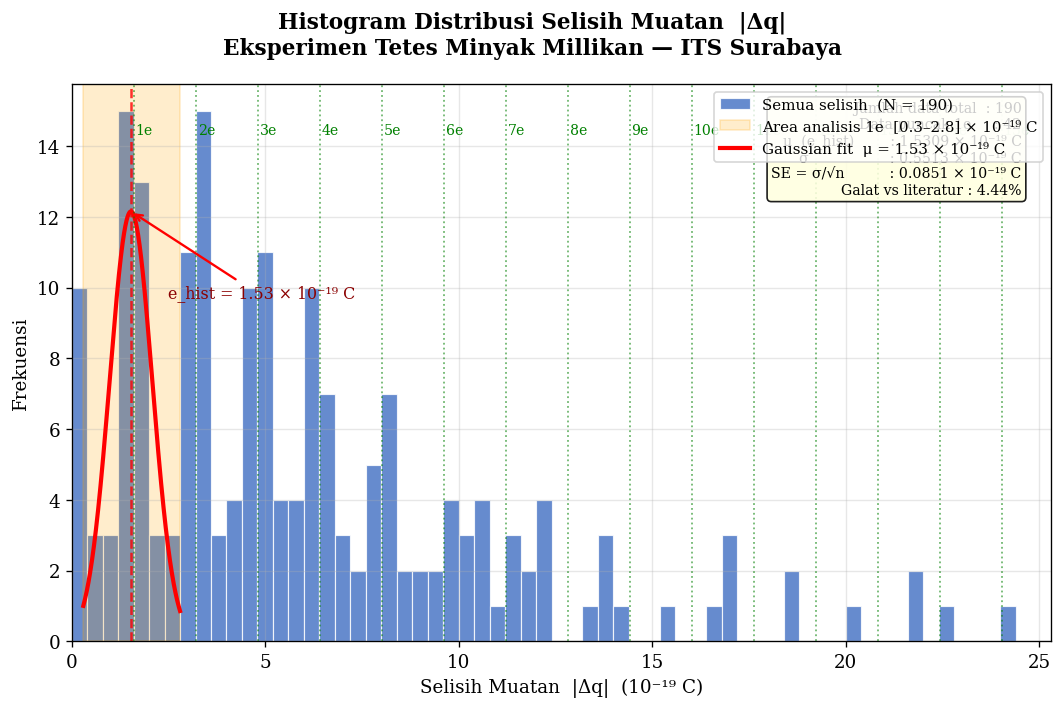

✅  Grafik histogram tersimpan sebagai 'millikan_histogram.png'


In [22]:
fig, ax1 = plt.subplots(figsize=(9, 6))
fig.suptitle(
    'Histogram Distribusi Selisih Muatan  |Δq|\n'
    'Eksperimen Tetes Minyak Millikan — ITS Surabaya',
    fontsize=13, fontweight='bold'
)

bin_width = 0.4
bins_all  = np.arange(0, selisih_19.max() + bin_width, bin_width)

ax1.hist(selisih_19, bins=bins_all,
         color='#4472C4', edgecolor='white', linewidth=0.7,
         alpha=0.82, label=f'Semua selisih  (N = {len(selisih)})')

ax1.axvspan(bawah/1e-19, atas/1e-19, alpha=0.20, color='orange',
            label=f'Area analisis 1e  [{bawah/1e-19:.1f}–{atas/1e-19:.1f}] × 10⁻¹⁹ C')

x_fit = np.linspace(bawah/1e-19, atas/1e-19, 400)
scale = len(peak1) * bin_width
y_fit = norm.pdf(x_fit, mu_g, std_g) * scale
ax1.plot(x_fit, y_fit, 'r-', linewidth=2.5,
         label=f'Gaussian fit  μ = {mu_g:.2f} × 10⁻¹⁹ C')
ax1.axvline(mu_g, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax1.annotate(
    f'  e_hist = {mu_g:.2f} × 10⁻¹⁹ C',
    xy=(mu_g, norm.pdf(mu_g, mu_g, std_g) * scale),
    xytext=(mu_g + 0.7, norm.pdf(mu_g, mu_g, std_g) * scale * 0.80),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.4),
    fontsize=9.5, color='darkred'
)

for k in range(1, int(selisih_19.max() / (e_ref/1e-19)) + 2):
    xk = k * (e_ref / 1e-19)
    if xk > selisih_19.max() * 1.05:
        break
    ax1.axvline(xk, color='green', linestyle=':', linewidth=1.1, alpha=0.55)
    ax1.text(xk + 0.05, ax1.get_ylim()[1] * 0.93 if ax1.get_ylim()[1] > 0 else scale * 1.4,
             f'{k}e', color='green', fontsize=8.5, va='top')

info = (f'Jumlah data total  : {len(selisih)}\n'
        f'Data puncak 1e     : {len(peak1)}\n'
        f'μ  (e_hist)        : {mu_g:.4f} × 10⁻¹⁹ C\n'
        f'σ                  : {std_g:.4f} × 10⁻¹⁹ C\n'
        f'SE = σ/√n          : {SE_g:.4f} × 10⁻¹⁹ C\n'
        f'Galat vs literatur : {galat_hist:.2f}%')
ax1.text(0.97, 0.97, info, transform=ax1.transAxes,
         fontsize=8.5, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.88))

ax1.set_xlabel('Selisih Muatan  |Δq|  (10⁻¹⁹ C)', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_xlim(0, selisih_19.max() * 1.05)
ax1.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('millikan_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Grafik histogram tersimpan sebagai 'millikan_histogram.png'")

## Cell 11 — Grafik Regresi Linear  q vs n

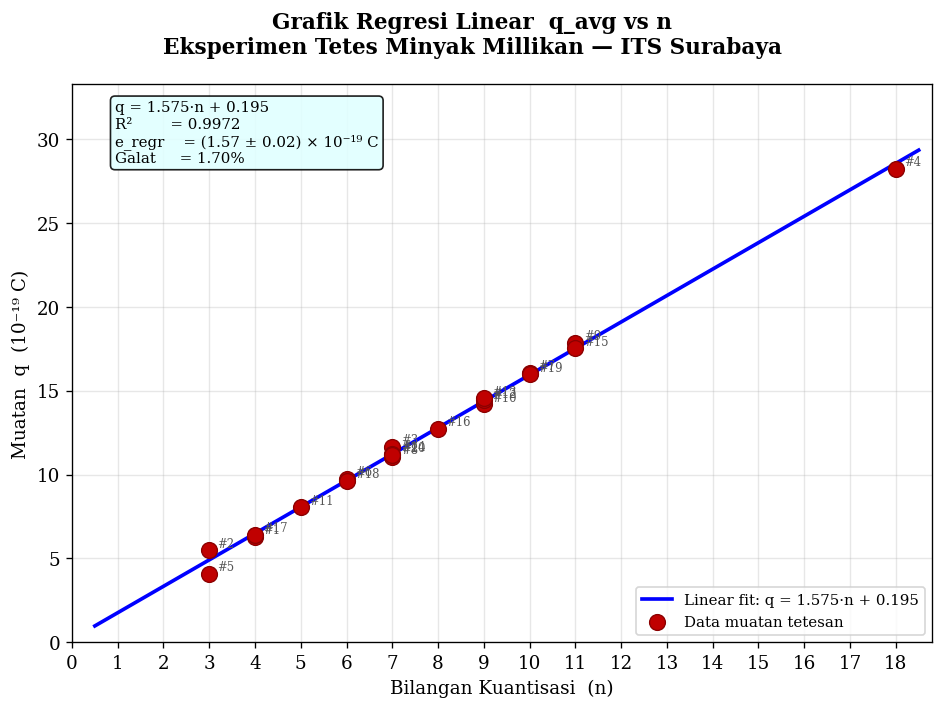

✅  Grafik regresi tersimpan sebagai 'millikan_regresi.png'


In [23]:
fig, ax2 = plt.subplots(figsize=(8, 6))
fig.suptitle(
    'Grafik Regresi Linear  q_avg vs n\n'
    'Eksperimen Tetes Minyak Millikan — ITS Surabaya',
    fontsize=13, fontweight='bold'
)

n_line = np.linspace(0.5, n_arr.max() + 0.5, 300)
q_line = np.polyval(koef, n_line)

ax2.plot(n_line, q_line, 'b-', linewidth=2.2,
         label=f'Linear fit: q = {m_reg:.3f}·n + {c_reg:.3f}')

ax2.scatter(n_arr, q_arr, color='#C00000', s=90, zorder=5,
            edgecolors='darkred', linewidth=0.8,
            label='Data muatan tetesan')

for _, row in df_h.iterrows():
    ax2.annotate(f"#{int(row['No'])}",
                 (row['n'], row['q_avg'] / 1e-19),
                 textcoords="offset points", xytext=(5, 2),
                 fontsize=7, color='#555')

info = (f'q = {m_reg:.3f}·n + {c_reg:.3f}\n'
        f'R²        = {R2:.4f}\n'
        f'e_regr    = ({m_reg:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C\n'
        f'Galat     = {galat_regr:.2f}%')
ax2.text(0.05, 0.97, info, transform=ax2.transAxes,
         fontsize=9, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.88))

ax2.set_xlabel('Bilangan Kuantisasi  (n)', fontsize=11)
ax2.set_ylabel('Muatan  q  (10⁻¹⁹ C)', fontsize=11)
ax2.set_xticks(range(0, int(n_arr.max()) + 2))
ax2.set_xlim(0, n_arr.max() + 0.8)
ax2.set_ylim(0, q_arr.max() * 1.18)
ax2.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('millikan_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Grafik regresi tersimpan sebagai 'millikan_regresi.png'")